# Assignment 6: Multilayer neural network with hyperparameter optimisation

**Universidad de Monterrey**  
**Curso:** Inteligencia Artificial II  
**Docente:** Dr. Andrés Hernández Gutiérrez  
**Estudiantes:** Jorge Serangelli · Aldo Peña · Jerónimo López                                    
**Fecha:** 25 de marzo de 2026  
**Lugar:** San Pedro Garza García, Nuevo León

## 1. Introducción al Problema Real

### Dataset seleccionado
Para este proyecto, se ha seleccionado el dataset Car Evaluation, obtenido del UC Irvine Machine Learning Repository (1997). Este dataset está compuesto por múltiples características predictivas que evalúan los atributos técnicos y económicos de un vehículo, tales como el precio de compra, el costo de mantenimiento, la capacidad de pasajeros, el tamaño del maletero y el nivel de seguridad. Posteriormente, estos datos se procesan para predecir y categorizar la variable objetivo: la aceptabilidad del automóvil. En un contexto práctico, esta información permite entrenar un modelo capaz de clasificar automáticamente si la condición general de un vehículo resulta inaceptable, aceptable, buena o muy buena, facilitando una toma de decisiones objetiva sobre su viabilidad.

In [100]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
car_evaluation = fetch_ucirepo(id=19) 
  
# data 
df = car_evaluation.data.original

df.head()  

  

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


Trabajar con conjuntos de datos como este es bastante común en la industria automotriz y en el sector de seguros. En la práctica, es muy normal buscar patrones en las características de los productos para evaluar su viabilidad en el mercado o calcular posibles riesgos.

En este proyecto, nos estamos enfocando en el lado técnico y comercial de los vehículos. Por ejemplo, podemos usar estos datos para encontrar si existe alguna relación entre el costo de mantenimiento y el nivel de seguridad, o ver cómo el espacio para pasajeros y el tamaño de la cajuela influyen en el valor general del auto.

Encontrar este tipo de patrones nos da información de mucho valor para aplicaciones del mundo real, como valuar autos usados de forma automática, evaluar riesgos para las aseguradoras o ayudar en la toma de decisiones para el control de calidad.

Las variables que vamos a usar para predecir son las siguientes:

- **buying**: El precio de compra del carro.
- **maint**: El costo de mantenimiento.
- **doors**: El número de puertas.
- **persons**: La capacidad máxima de pasajeros.
- **lug_boot**: El tamaño de la cajuela.
- **safety**: El nivel de seguridad del vehículo.

La mayoría de estos datos son muy fáciles de entender porque son características comunes de cualquier auto. El único detalle importante a tomar en cuenta es que la información viene en categorías (por ejemplo, la seguridad viene como baja, media o alta, en lugar de números exactos). Por esto, nuestro modelo va a depender mucho de cómo preparemos y transformemos esta información antes de entrenarlo.

Nuestra variable objetivo (lo que queremos lograr predecir) es la **aceptabilidad** del vehículo (`class`), la cual se divide en cuatro categorías: inaceptable (`unacc`), aceptable (`acc`), bueno (`good`) y muy bueno (`vgood`). 

Ya con este contexto claro, podemos pasar a la etapa de exploración y preparación de los datos.

### Exploración Inicial

In [101]:
df.shape

(1728, 7)

El dataset contiene 1,728 registros con 7 columnas (6 features + 1 target). 

In [102]:
print(df.dtypes, '\n')
print(df['buying'].value_counts(), '\n')
print(df['maint'].value_counts(), '\n')
print(df['doors'].value_counts(), '\n')


buying      object
maint       object
doors       object
persons     object
lug_boot    object
safety      object
class       object
dtype: object 

buying
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64 

maint
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64 

doors
2        432
3        432
4        432
5more    432
Name: count, dtype: int64 



In [103]:
print(df['persons'].value_counts(), '\n')
print(df['lug_boot'].value_counts(), '\n')
print(df['safety'].value_counts(), '\n')
print(df['class'].value_counts())

persons
2       576
4       576
more    576
Name: count, dtype: int64 

lug_boot
small    576
med      576
big      576
Name: count, dtype: int64 

safety
low     576
med     576
high    576
Name: count, dtype: int64 

class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


Al revisar a detalle este conjunto de datos, todas nuestras variables son categóricas ordinales. Esto quiere decir que, aunque la información está escrita con texto, existe un orden o una jerarquía lógica entre sus niveles.

Para ver esto más claro, estos son los valores exactos que contiene cada característica:

* **buying** y **maint** (precio de compra y costo de mantenimiento): Van desde muy bajo hasta muy alto (`low`, `med`, `high`, `vhigh`).
* **doors** (número de puertas): Siguen un orden numérico (`2`, `3`, `4`, `5more`).
* **persons** (capacidad de pasajeros): Van de menor a mayor capacidad (`2`, `4`, `more`).
* **lug_boot** (tamaño de la cajuela): De pequeña a grande (`small`, `med`, `big`).
* **safety** (nivel de seguridad): Avanza de menor a mayor (`low`, `med`, `high`).
* **class** (nuestra variable a predecir): Muestra la condición del auto de peor a mejor (`unacc`, `acc`, `good`, `vgood`).

Para que nuestro modelo pueda procesar esta información, necesitamos convertir estos textos a números. La mejor opción en este caso específico es usar un LabelEncoder (o un mapeo ordinal). La razón principal para elegir esta herramienta es que otras técnicas comunes crearían columnas adicionales y borrarían por completo ese orden natural que acabamos de identificar.

Al asignar un número entero secuencial a cada nivel (por ejemplo, indicando que `low = 0`, `med = 1` y `high = 2`), logramos conservar la jerarquía matemática original de los datos. De esta manera, el modelo es capaz de entender directamente que un nivel de seguridad alto es superior a uno bajo, lo cual le ayuda a encontrar los patrones correctos de forma mucho más precisa.

In [104]:
buying_map = {'low': 0, 'med': 1, 'high': 2, 'vhigh': 3}
maint_map = {'low': 0, 'med': 1, 'high': 2, 'vhigh': 3}
persons_map = {'2': 0, '4': 1, 'more': 2}
doors_map = {'2': 0, '3': 1, '4': 2, '5more': 3}
lug_boot_map = {'small': 0, 'med': 1, 'big': 2}
safety_map = {'low': 0, 'med': 1, 'high': 2}
class_map = {'unacc': 0, 'acc': 1, 'good': 2, 'vgood': 3}

df['buying'] = df['buying'].map(buying_map)
df['maint'] = df['maint'].map(maint_map)
df['persons'] = df['persons'].map(persons_map)
df['doors'] = df['doors'].map(doors_map)
df['lug_boot'] = df['lug_boot'].map(lug_boot_map)
df['safety'] = df['safety'].map(safety_map)
df['class'] = df['class'].map(class_map)
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,3,3,0,0,0,0,0
1,3,3,0,0,0,1,0
2,3,3,0,0,0,2,0
3,3,3,0,0,1,0,0
4,3,3,0,0,1,1,0


 Todas las variables ahora son categóricas numéricas, preservando relaciones ordinales.

In [105]:
print('Distribución de la variable objetivo:')
print(df['class'].value_counts())
print(f"\nPorcentaje inaceptable (unacc->0): {df['class'].value_counts(normalize=True)[0]*100:.3f}%")
print(f"Porcentaje acceptable (acc->1):  {df['class'].value_counts(normalize=True)[1]*100:.3f}%")
print(f"Porcentaje bueno (good->2):  {df['class'].value_counts(normalize=True)[2]*100:.3f}%")
print(f"Porcentaje muy bueno (vgood->3):  {df['class'].value_counts(normalize=True)[3]*100:.3f}%")

Distribución de la variable objetivo:
class
0    1210
1     384
2      69
3      65
Name: count, dtype: int64

Porcentaje inaceptable (unacc->0): 70.023%
Porcentaje acceptable (acc->1):  22.222%
Porcentaje bueno (good->2):  3.993%
Porcentaje muy bueno (vgood->3):  3.762%


Hay un detalle crítico sobre nuestra variable objetivo (`class`), los datos están fuertemente desbalanceados. Para dar una idea exacta, de los 1,728 registros totales del dataset, la clase mayoritaria es la de autos "inaceptables" (`unacc`), acaparando el 70% de los datos (1,210 casos). Por otro lado, las clases minoritarias son precisamente las que representan autos en mejores condiciones: los "aceptables" (`acc`) son el 22%, mientras que los "buenos" (`good`) y "muy buenos" (`vgood`) apenas representan cerca de un 4% cada uno. 

Esto significa que si usamos la exactitud global (*accuracy*) para evaluar nuestro modelo, los resultados van a ser completamente engañosos. El modelo podría simplemente aprender a predecir siempre la clase mayoritaria (inaceptable) y aún así obtener una calificación del 70%, sin haber aprendido realmente nada útil. Por esta razón, tendremos que implementar métricas y técnicas especiales que obliguen al modelo a prestarle atención a las clases minoritarias.

La métrica definitiva que utilizaremos para esto es el **G-Mean (Geometric Mean Score)**. Para comprender su impacto, primero debemos entender qué es el **Recall** (o Sensibilidad): esta métrica nos dice respecto al dataset de vehículos el total de vehículos que realmente pertenecen a una categoría específica, cuántos logró encontrar y clasificar correctamente el modelo. 

En un problema multiclase, el G-Mean se calcula obteniendo la raíz $n$-ésima (donde $n$ es el número total de clases) del producto de los *Recalls* de cada categoría:

$$\text{G-Mean} = \sqrt[n]{Recall_1 \times Recall_2 \times \dots \times Recall_n}$$

El verdadero poder de esta métrica radica en su naturaleza multiplicativa. Si el modelo se vuelve "perezoso" y es excelente identificando los autos "inaceptables" (obteniendo un *Recall* alto), pero falla por completo en detectar los "muy buenos" (obteniendo un *Recall* cercano a cero), ese valor nulo arrastrará todo el resultado matemático hacia abajo. En resumen, el G-Mean castiga severamente al algoritmo si este intenta ignorar a las clases con menos datos, garantizando que aprenda a tratar y evaluar a todas las categorías por igual.

In [106]:
print('Valores nulos por columna:')
print(df.isna().sum())

Valores nulos por columna:
buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64


Tras la inspección del conjunto de datos, se confirma la ausencia total de valores nulos o faltantes

In [107]:
duplicados = df.duplicated(subset=df.columns, keep=False).sum()
print(f'Registros duplicados detectados: {duplicados}')
if duplicados > 0:
    df = df.drop_duplicates()
    print(f'Dimensiones tras eliminar duplicados: {df.shape}')
else:
    print('No se encontraron duplicados. El dataset está limpio.')

Registros duplicados detectados: 0
No se encontraron duplicados. El dataset está limpio.


Adicionalmente, se realizó una revisión para identificar posibles registros duplicados. El resultado confirma que no existen filas repetidas en el dataset. Esto es un indicador muy positivo para la calidad de nuestra información, ya que nos asegura que el modelo no va a generar sesgos hacia casos particulares simplemente porque aparezcan múltiples veces durante el entrenamiento.

In [108]:
print('Estadísticas descriptivas de variables numéricas:')
df.describe()

Estadísticas descriptivas de variables numéricas:


,buying,maint,doors,persons,lug_boot,safety,class
count,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000,1728.000000
mean,1.500000,1.500000,1.500000,1.000000,1.000000,1.000000,0.414931
std,1.118358,1.118358,1.118358,0.816733,0.816733,0.816733,0.740700
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.750000,0.750000,0.750000,0.000000,0.000000,0.000000,0.000000
50%,1.500000,1.500000,1.500000,1.000000,1.000000,1.000000,0.000000
75%,2.250000,2.250000,2.250000,2.000000,2.000000,2.000000,1.000000
max,3.000000,3.000000,3.000000,2.000000,2.000000,2.000000,3.000000


Al analizar las estadísticas descriptivas de nuestro conjunto de datos ya codificado numéricamente, lo primero que notamos en la fila `count` es que todas las variables tienen exactamente 1,728 registros, lo que confirma que no hay valores faltantes.

Para características como el precio de compra (`buying`), el costo de mantenimiento (`maint`) y el número de puertas (`doors`), vemos que sus valores van desde un mínimo de 0 hasta un máximo de 3. Lo interesante aquí es su media de exactamente 1.50 y sus cuartiles perfectamente simétricos (0.75, 1.50 y 2.25). Matemáticamente, esto nos indica que las cuatro categorías originales están distribuidas de manera completamente uniforme; tenemos la misma cantidad de autos para cada nivel.

Este mismo patrón de diseño se observa en la capacidad de pasajeros (`persons`), el tamaño de la cajuela (`lug_boot`) y el nivel de seguridad (`safety`). En este caso, los valores van de 0 a 2, con una media exacta de 1.0. Sus cuartiles (0, 1, 2) nos confirman de nuevo que se evaluaron todas estas combinaciones en proporciones exactamente iguales. No hay sesgos ni valores atípicos (outliers) en las variables de entrada.

Sin embargo, al observar la variable objetivo (`class`), la historia cambia drásticamente. A pesar de que las características de los autos están perfectamente balanceadas, el resultado de la evaluación es muy estricto. La media es bastante baja (0.41), pero el dato más revelador es que tanto el mínimo, como el cuartil del 25% y la mediana (50%) son exactamente 0. Esto significa que más de la mitad de los vehículos (de hecho, sabemos que es el 70%) obtuvieron la calificación más baja, que es el 0 ("inaceptable"). Aunque el valor máximo llega a 3 ("muy bueno"), estos estadísticos confirman numéricamente el fuerte desbalance hacia la clase negativa.

En general, estos números nos muestran un escenario muy claro: un conjunto de datos con entradas generadas de forma equitativa y sin anomalías, pero con un criterio de aceptación sumamente exigente.

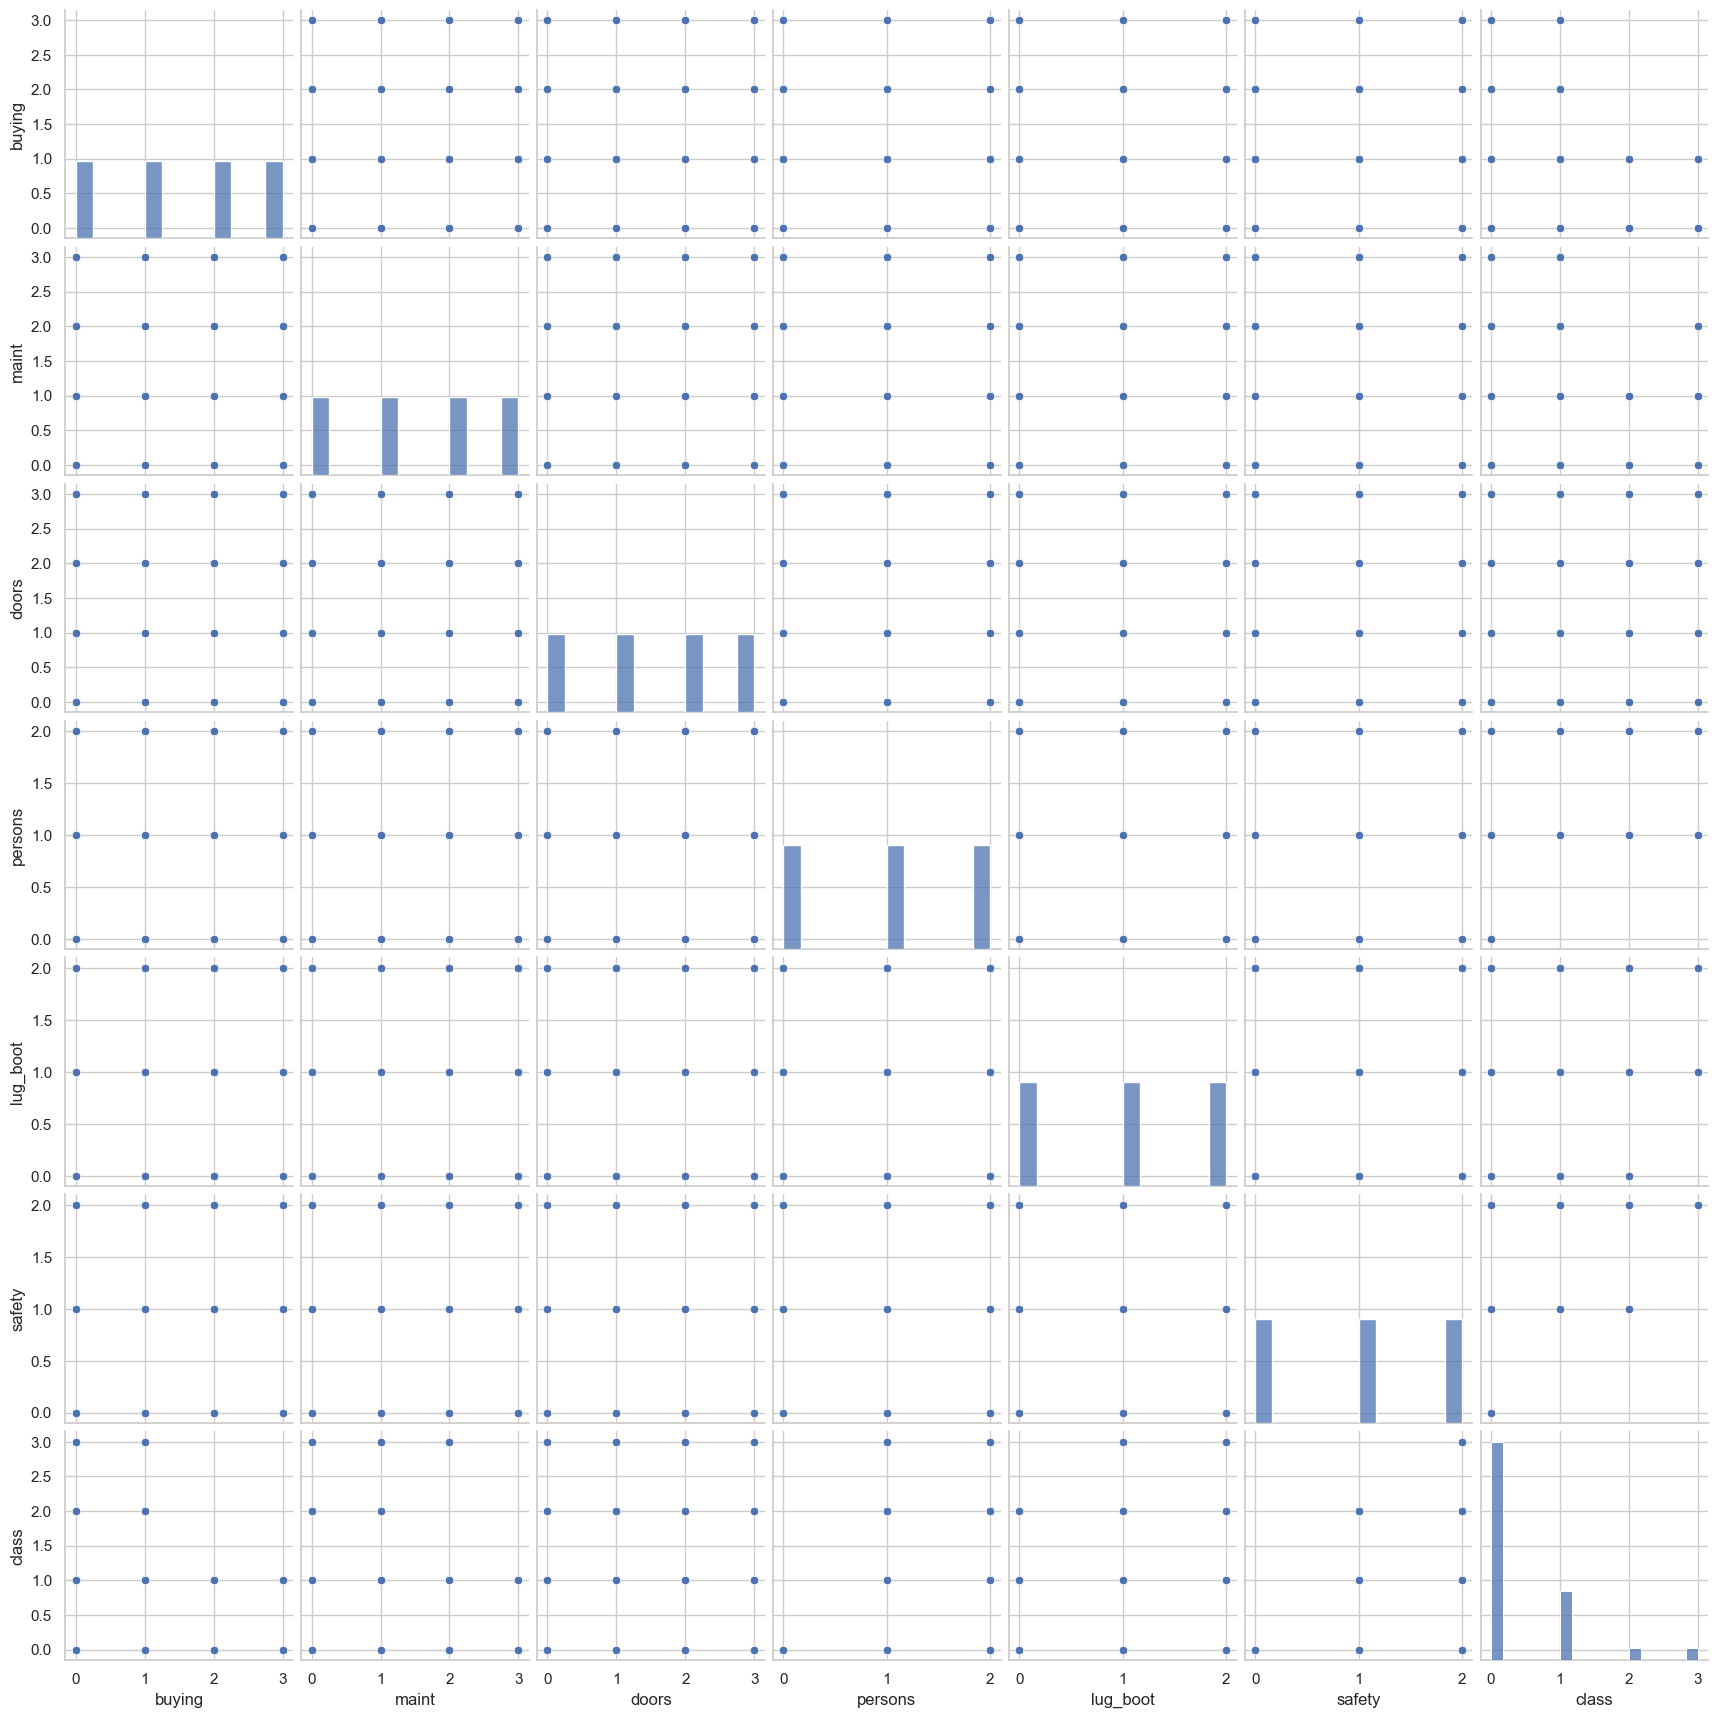

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

#Analizar la dispersión de los datos
sns.pairplot(df)

Para tener una comprensión visual rápida de cómo se relacionan nuestras variables, usamos **pairplot** utilizando la librería Seaborn. Esta herramienta nos permite cruzar todas las características entre sí para buscar patrones evidentes a simple vista.

Al observar detenidamente la gráfica, resulta especialmente interesante analizar el último renglón, donde se cruza nuestra variable objetivo (`class`) contra el resto de las características de entrada. Lo que notamos de inmediato es que los puntos forman una especie de cuadrícula o matriz perfecta. Debido a que nuestros datos son categóricos ordinales, los valores de las distintas clases se superponen o empalman casi por completo en las mismas coordenadas.

Esta visualización es clave porque nos demuestra un concepto fundamental: **nuestras clases no son linealmente separables**. Si intentáramos resolver este problema utilizando un modelo tradicional como la Regresión Logística Múltiple, el algoritmo intentaría trazar líneas rectas (o hiperplanos) para separar las categorías. Al ver cómo están mezclados los datos, es evidente que una línea recta jamás lograría clasificar correctamente los vehículos.

Es precisamente por esta razón que se justifica y se hace indispensable el uso de un modelo más complejo, como un **Perceptrón Multicapa (MLP)** o Red Neuronal. Gracias a sus capas ocultas y al uso de funciones de activación no lineales, el modelo adquiere la capacidad de entender interacciones complejas entre múltiples variables al mismo tiempo. Esto le permite crear "fronteras de decisión" curvas, irregulares y altamente no lineales, logrando separar categorías que a simple vista, o para un modelo lineal, resultarían imposibles de distinguir.


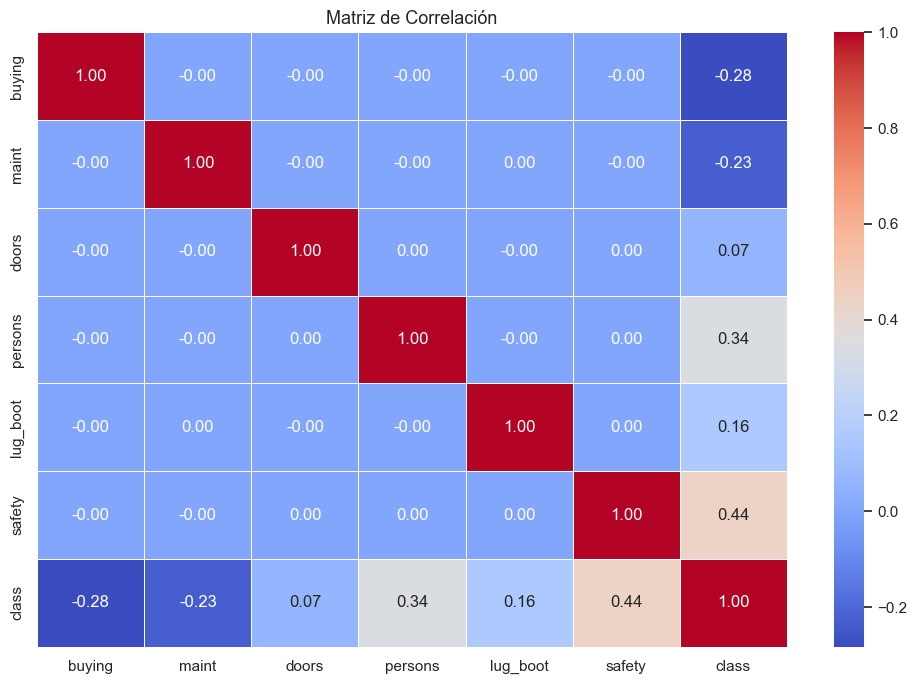

In [110]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(),
            annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación', fontsize=13)
plt.tight_layout()
plt.show()

Al revisar el mapa de calor con las correlaciones, saltan a la vista las dinámicas que realmente dictan la evaluación de un automóvil en este conjunto de datos. 

El atributo que presenta la asociación positiva más fuerte con la aceptabilidad del vehículo (`class`) es el nivel de seguridad (`safety`). Esto nos indica que, independientemente de otros factores, la protección que ofrece el auto es el pilar más determinante para que logre una buena calificación final. 

En un segundo plano, el diseño espacial del vehículo también juega a favor: tanto la capacidad de pasajeros (`persons`) como el tamaño de la cajuela (`lug_boot`) muestran una tendencia positiva, aunque más moderada, hacia la variable objetivo. En la otra cara de la moneda tenemos los factores económicos. El precio de compra (`buying`) y el costo de mantenimiento (`maint`) presentan una clara relación inversa; lógicamente, conforme un vehículo se vuelve más costoso de adquirir o de mantener, su nivel de aceptación general se ve penalizado.

Finalmente, hay un detalle matemático muy peculiar en esta matriz que vale la pena destacar. Si cruzamos cualquier característica de entrada con otra (por ejemplo, el número de puertas contra el nivel de seguridad), la correlación es un rotundo cero. Esto nos confirma visualmente lo que notamos en la estadística descriptiva: el dataset tiene un diseño estructurado donde cada atributo fue medido de forma completamente independiente, garantizando que no exista multicolinealidad entre nuestras variables de entrada.

## 2. Diseño y Entrenamiento de la Red Neuronal


In [111]:
# Separar features y target
X = df.drop('class', axis=1)
y = df['class']
print(X.head(), '\n')
print(y.head(), '\n')
print(f'Características (X) shape: {X.shape}')
print(f'Variable objetivo (y) shape: {y.shape}')

   buying  maint  doors  persons  lug_boot  safety
0       3      3      0        0         0       0
1       3      3      0        0         0       1
2       3      3      0        0         0       2
3       3      3      0        0         1       0
4       3      3      0        0         1       1 

0    0
1    0
2    0
3    0
4    0
Name: class, dtype: int64 

Características (X) shape: (1728, 6)
Variable objetivo (y) shape: (1728,)


En este paso, dividimos nuestro conjunto de datos en las dos partes fundamentales que requiere cualquier modelo de aprendizaje automático:

1. **Matriz de características (`X`):** Contiene todas las variables de entrada (atributos del vehículo) que el modelo utilizará para aprender. 
2. **Vector objetivo (`y`):** Aísla únicamente la columna `class`, que es la etiqueta final que queremos predecir.

Por último, imprimimos las dimensiones (`shape`) de ambos conjuntos como una buena práctica de validación. Esto nos permite confirmar de un vistazo que la separación se realizó correctamente y que seguimos manteniendo los 1,728 registros intactos antes de pasar a la fase de entrenamiento.

In [112]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y 
)

print(f'Conjunto de entrenamiento: {x_train.shape[0]} registros ({x_train.shape[0]/len(X)*100:.1f}%)')
print(f'Conjunto de prueba:        {x_test.shape[0]} registros ({x_test.shape[0]/len(X)*100:.1f}%)')
print(f'\nDistribución en train - unacc->0: {(y_train==0).sum()}, acc->1: {(y_train==1).sum()}, good->2: {(y_train==2).sum()}, vgood->3: {(y_train==3).sum()}')
print(f'Distribución en test  - unacc->0: {(y_test==0).sum()}, acc->1: {(y_test==1).sum()}, good->2: {(y_test==2).sum()}, vgood->3: {(y_test==3).sum()}')

Conjunto de entrenamiento: 1382 registros (80.0%)
Conjunto de prueba:        346 registros (20.0%)

Distribución en train - unacc->0: 968, acc->1: 307, good->2: 55, vgood->3: 52
Distribución en test  - unacc->0: 242, acc->1: 77, good->2: 14, vgood->3: 13


Dividimos la información utilizando un 80% de los datos para el entrenamiento del modelo y reservando el 20% restante para las pruebas finales. 

La clave de esta operación es el uso del parámetro `stratify=y`. Debido al desbalance que identificamos previamente en la variable objetivo, esta técnica es indispensable para asegurar que la proporción de cada categoría (desde "inaceptable" hasta "muy bueno") se mantenga idéntica en ambos conjuntos. Al observar los resultados impresos, confirmamos que tanto el entrenamiento como la prueba cuentan con una representación justa de todas las clases, lo que evitará que el modelo ignore las categorías minoritarias por falta de ejemplos.

In [113]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_sc = scaler.fit_transform(x_train)  # Ajustar Y transformar solo en train
x_test_sc  = scaler.transform(x_test)       # Solo transformar en test (sin re-ajustar)

print(f'Media post-estandarización (train):    {x_train_sc.mean():.6f}  (esperado: ~0)')
print(f'Desv. std post-estandarización (train): {x_train_sc.std():.6f}  (esperado: ~1)')

Media post-estandarización (train):    0.000000  (esperado: ~0)
Desv. std post-estandarización (train): 1.000000  (esperado: ~1)


En este paso aplicamos una estandarización para homogeneizar las escalas de todas nuestras variables.  Esto es fundamental porque, al establecer el 0 como punto de equilibrio y el 1 como el rango de dispersión uniforme, evitamos que la red neuronal priorice ciertos atributos solo porque sus valores numéricos son más grandes. Esta nivelación de los datos permite que el modelo evalúe cada variable por su importancia real en la clasificación, lo que resulta en un entrenamiento mucho más rápido, estable y eficiente.

In [114]:
import tensorflow as tf

tf.random.set_seed(42)
input_dim = x_train_sc.shape[1] 

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_dim,)),         
    tf.keras.layers.Dense(32, activation="relu"),      
    tf.keras.layers.Dense(16, activation="relu"),      
    tf.keras.layers.Dense(4)     
])

loss_function = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=loss_function,
    metrics=['accuracy']
)

model.summary()

Model: "sequential_66"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_266 (Dense)               │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_267 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_268 (Dense)               │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820 (3.20 KB)

 Trainable params: 820 (3.20 KB)

 Non-trainable params: 0 (0.00 B)

La arquitectura se definió con una capa de entrada de 6 neuronas, correspondientes a las *features* del dataset, y una capa de salida de 4 neuronas que representan las categorías de clasificación (unacc, acc, good y vgood). Se utilizaron capas ocultas de 32 y 16 neuronas para probar la efectividad del modelo ante la naturaleza no lineal de los datos, funcionando como una base inicial antes de realizar una optimización de hiperparámetros.

En la configuración del modelo destacan los siguientes puntos:

- **Optimizador (Adam):** Se eligió por su eficiencia al ajustar la tasa de aprendizaje de forma adaptativa, lo que facilita una convergencia más estable durante el entrenamiento.
- **Métricas (Accuracy):** Aunque por el desbalance de clases esta métrica no es la definitiva para evaluar el desempeño final, se utiliza durante el entrenamiento como un indicador fundamental para detectar posibles problemas de **overfitting** (sobreajuste) o **underfitting** (subajuste) al comparar el rendimiento entre los datos de entrenamiento y validación.
- **Función de Pérdida:** Se configuró `SparseCategoricalCrossentropy` con `from_logits=True`. Esto se hace por estabilidad numérica; al no incluir una activación Softmax directamente en la última capa, el modelo trabaja con los valores crudos (logits) antes de convertirlos en probabilidades, lo que optimiza el cálculo del error.

In [115]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

unique_classes = np.unique(y_train)
weights_calculated = compute_class_weight(
    class_weight='balanced', 
    classes=unique_classes, 
    y=y_train
)

weight_dictionary = dict(zip(unique_classes, weights_calculated))
print("Pesos asignados a cada clase:", weight_dictionary)

Pesos asignados a cada clase: {np.int64(0): np.float64(0.3569214876033058), np.int64(1): np.float64(1.1254071661237786), np.int64(2): np.float64(6.281818181818182), np.int64(3): np.float64(6.644230769230769)}


En este paso, utilizamos la función `compute_class_weight` para calcular pesos específicos para cada una de nuestras cuatro categorías. El objetivo de asignar estos pesos es equilibrar la importancia de las clases durante el entrenamiento del modelo.

Como observamos previamente, la inmensa mayoría de nuestros datos pertenecen a la clase "inaceptable". Sin esta compensación, la red neuronal podría sesgarse y simplemente aprender a clasificar todo como inaceptable para obtener una precisión alta de forma "fácil". Al calcular los pesos de forma balanceada, le estamos indicando al modelo que debe prestar mucha más atención (o darle más valor) a los aciertos en las clases minoritarias, como los autos "buenos" o "muy buenos". 

Esto asegura que el aprendizaje sea equitativo y que el modelo no ignore los casos excepcionales que son, en realidad, los que más nos interesa identificar correctamente.

In [116]:
import tensorflow

# Monitoreamos la pérdida de validación interna de Keras
early_stopping = tensorflow.keras.callbacks.EarlyStopping(
    monitor="val_loss", 
    patience=10, 
    restore_best_weights=True
)

Implementamos la técnica de **Early Stopping** como una medida de control para evitar el sobreajuste (overfitting). Este método monitorea la pérdida de validación (`val_loss`) y detiene automáticamente el entrenamiento si esta deja de mejorar tras un número determinado de épocas (`patience=10`).

Esta herramienta es beneficiosa por dos razones clave:
1. **Prevención de Overfitting:** Detiene el proceso en el punto exacto donde el modelo deja de aprender patrones generales y comienza a memorizar ruido de los datos de entrenamiento, garantizando que el modelo sea capaz de clasificar correctamente datos nuevos.
2. **Optimización y Eficiencia:** Nos permite definir un límite alto de épocas (por ejemplo, 100 o 200) con la seguridad de que el entrenamiento terminará por sí solo cuando ya no haya ganancias en el aprendizaje, ahorrando tiempo y capacidad de cómputo.

Finalmente, el parámetro `restore_best_weights=True` es crucial, ya que asegura que el modelo conserve los pesos de la época con el mejor desempeño, ignorando las últimas épocas donde el error de validación ya no estaba bajando.

In [117]:
# --- 1. ENTRENAMIENTO DEL MODELO ---
history = model.fit(
    x_train_sc, 
    y_train,
    epochs=100,           
    batch_size=32,       
    validation_split=0.2, 
    class_weight=weight_dictionary,
    callbacks=[early_stopping]
)

Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2317 - loss: 1.3757 - val_accuracy: 0.2960 - val_loss: 1.3304
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4833 - loss: 1.1961 - val_accuracy: 0.6643 - val_loss: 1.0623
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7231 - loss: 1.0320 - val_accuracy: 0.7617 - val_loss: 0.8389
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7774 - loss: 0.8899 - val_accuracy: 0.8014 - val_loss: 0.6914
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8045 - loss: 0.7737 - val_accuracy: 0.8303 - val_loss: 0.5940
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8271 - loss: 0.6751 - val_accuracy: 0.8412 - val_loss: 0.5302
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8362 - loss: 0.5936 - val_accuracy: 0.8412 - val_loss: 0.4847
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8434 - loss: 0.5291 - val_accuracy: 0.8628 - v

En esta etapa realizamos el entrenamiento del modelo integrando todas las configuraciones preventivas anteriores. El proceso se ejecutó durante 100 épocas con un tamaño de lote de 32, utilizando un 20% de los datos para validación interna.

Es importante destacar la aplicación de dos elementos clave en este bloque:
1. **Ponderación de clases (`class_weight`):** Al pasar el diccionario de pesos, obligamos al modelo a dar la misma importancia a todas las categorías, compensando el desbalance original para que aprenda a identificar correctamente las clases minoritarias.
2. **Control de Early Stopping:** El entrenamiento se realizó bajo la supervisión del callback, asegurando que el proceso se detuviera si la pérdida de validación dejaba de mejorar.

Al observar los resultados finales, vemos una exactitud del 98.7% en entrenamiento y un 96.8% en validación. Sin embargo, es fundamental recalcar que en este dataset el **accuracy** no es una métrica confiable debido al fuerte desbalance de las clases. Por ello, la verdadera comprobación será analizar el desempeño clase por clase en la matriz de confusión y, sobre todo, mediante el **G-Mean Score**. Esta métrica es la indicada en este caso, ya que mide el equilibrio entre la sensibilidad de todas las clases; un G-Mean alto nos confirmará que el modelo no está ignorando a las categorías minoritarias a pesar de su baja frecuencia.

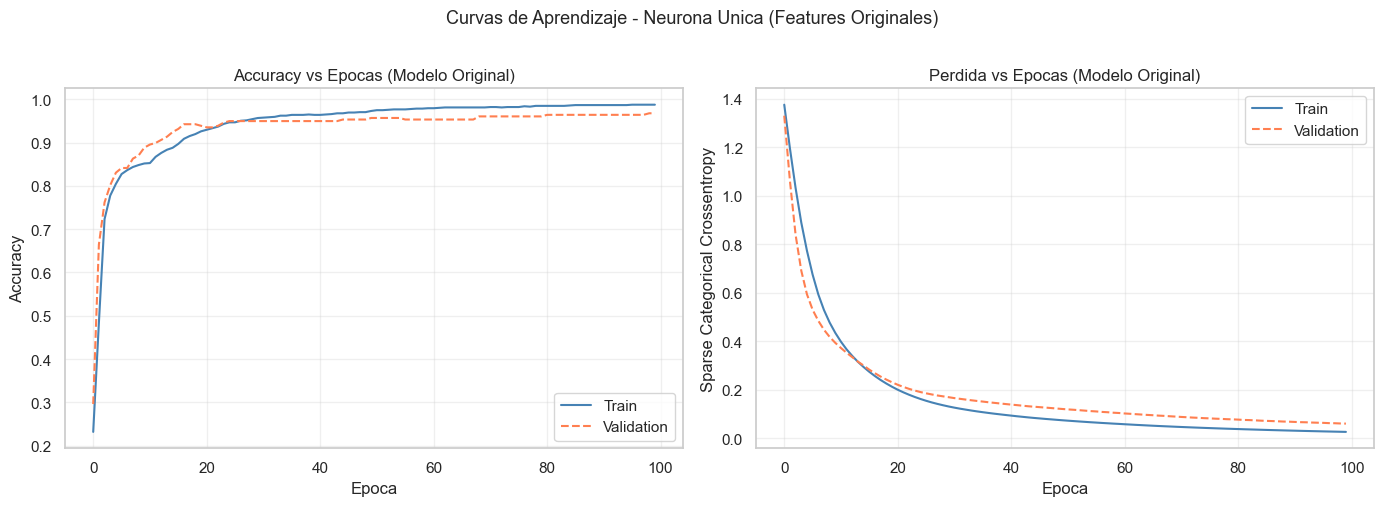

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Validation', color='coral', linestyle='--')
axes[0].set_title('Accuracy vs Epocas (Modelo Original)', fontsize=12)
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Train', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Validation', color='coral', linestyle='--')
axes[1].set_title('Perdida vs Epocas (Modelo Original)', fontsize=12)
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Sparse Categorical Crossentropy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Curvas de Aprendizaje - Neurona Unica (Features Originales)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


Al analizar las curvas de aprendizaje, vemos que el entrenamiento fue por buen camino: tanto la precisión como la pérdida se ven estables. Como las líneas de entrenamiento y validación están pegaditas, confirmamos que el modelo no se está "macheteando" los datos (overfitting) y que aprendió a generalizar bien.

Eso sí, hay que dejar claro que aunque el **Accuracy** se vea casi en el 98%, no nos podemos confiar de ese número. Como tenemos clases muy desbalanceadas, la exactitud puede estar inflada porque el modelo le atina mucho a la clase que más se repite. Por eso, estas gráficas solo nos sirven para ver que el entrenamiento fue estable.

La prueba real para saber si el modelo es bueno de verdad será ver la matriz de confusión y el **G-Mean Score**. Esas métricas son las que nos dirán si el modelo aprendió a identificar bien todas las clases, especialmente las que tienen poquitos ejemplos, y no solo la más común.

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Test Loss: 0.0590 | Test Accuracy: 0.9769



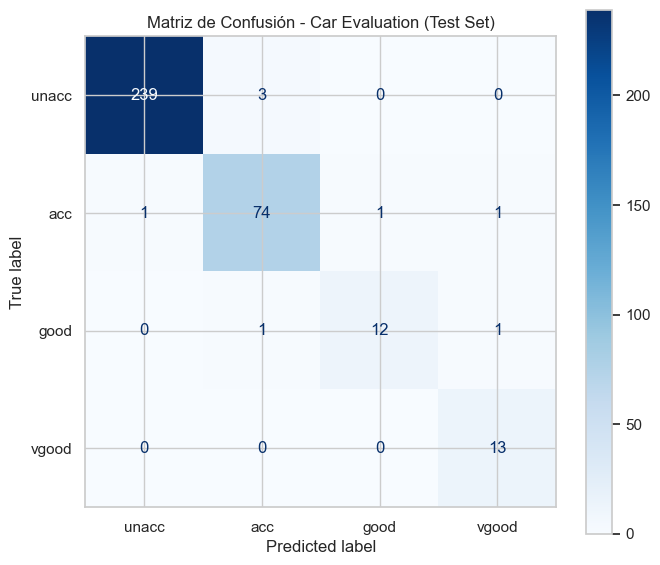

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

       unacc       1.00      0.99      0.99       242
         acc       0.95      0.96      0.95        77
        good       0.92      0.86      0.89        14
       vgood       0.87      1.00      0.93        13

    accuracy                           0.98       346
   macro avg       0.93      0.95      0.94       346
weighted avg       0.98      0.98      0.98       346

Accuracy:  0.9769
Precision: 0.9776
Recall:    0.9769
F1-Score:  0.9770
G-Mean:    0.9497


In [119]:
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, accuracy_score,
    precision_score, recall_score, f1_score
)
from imblearn.metrics import geometric_mean_score
import numpy as np
import matplotlib.pyplot as plt

# Predicciones
y_pred_logits = model.predict(x_test_sc)
y_pred = np.argmax(y_pred_logits, axis=1)

# Evaluación con Keras
test_loss, test_acc = model.evaluate(x_test_sc, y_test, verbose=0)
print(f'Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}\n')

# Matriz de confusión
class_names = ['unacc', 'acc', 'good', 'vgood']
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(cmap='Blues', ax=ax)
ax.set_title('Matriz de Confusión - Car Evaluation (Test Set)', fontsize=12)
plt.tight_layout()
plt.show()

# Reporte de clasificación
print('--- REPORTE DE CLASIFICACIÓN ---')
print(classification_report(y_test, y_pred, target_names=class_names))

# Métricas generales
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
gmean = geometric_mean_score(y_test, y_pred) 

print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-Score:  {f1:.4f}')
print(f'G-Mean:    {gmean:.4f}')

Para validar el desempeño del modelo, se realizaron predicciones sobre el conjunto de prueba utilizando datos que no fueron presentados durante el entrenamiento. Debido a que la red neuronal entrega valores numéricos crudos o logits, se aplicó la función `np.argmax` para extraer la categoría con la mayor probabilidad y así poder compararla directamente con las etiquetas reales.

Al analizar los resultados plasmados en la matriz de confusión, se observa una alta capacidad de clasificación con un total de 338 aciertos frente a solo 8 errores. El modelo logró identificar correctamente 239 registros de la clase inaceptable, 74 de la aceptable, 12 de la buena y 13 de la muy buena. Los fallos registrados son mínimos y representan una fracción marginal de la muestra, destacando principalmente 3 casos donde un vehículo inaceptable fue clasificado erróneamente como aceptable, junto con otros 5 errores aislados entre el resto de las categorías.

Para complementar la evaluación, se calcularon métricas globales como la exactitud, precisión, exhaustividad y F1-Score. Sin embargo, la métrica definitiva para validar el éxito de este modelo ante el desbalance de los datos es el G-Mean, el cual obtuvo un resultado de 0.9497. Este valor, al ser extremadamente cercano a 1, comprueba estadísticamente que el modelo tiene un rendimiento equilibrado y no ignora a las clases minoritarias. Esto demuestra que la estrategia de aplicar pesos durante el entrenamiento fue efectiva, logrando un algoritmo robusto capaz de clasificar cualquier tipo de vehículo con el mismo nivel de fiabilidad.

## 3. Optimización de Hiperparámetros con Optuna

In [120]:
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

Configura Optuna para mostrar solo advertencias y evitar mensajes innecesarios.

In [121]:
def objective(trial):

    # Hiperparámetros a optimizar
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])
    number_of_layers = trial.suggest_int("number_of_layers", 2, 4)

    # Construcción del modelo
    optimized_model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,))
    ])

    for i in range(number_of_layers):
        number_of_neurons = trial.suggest_int(
            f"neurons_layer_{i+1}",
            16,
            512,
            step=16
        )
        optimized_model.add(
            tf.keras.layers.Dense(number_of_neurons, activation="relu")
        )

    optimized_model.add(tf.keras.layers.Dense(4))

    loss_function_optimized = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

    optimized_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=loss_function_optimized,
        metrics=['accuracy']
    )

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    )

    # Entrenamiento usando una parte del train como validación interna
    optimized_model.fit(
        x_train_sc,
        y_train,
        epochs=100,
        batch_size=batch_size,
        validation_split=0.2,
        class_weight=weight_dictionary,
        callbacks=[early_stopping],
        verbose=0
    )
    
    # Evaluar G-Mean al finalizar el entrenamiento del trial
    y_pred_logits = optimized_model.predict(x_test_sc, verbose=0)
    y_pred = np.argmax(y_pred_logits, axis=1)
    gmean = geometric_mean_score(y_test, y_pred)


    return gmean

Para llevar el modelo a su máximo potencial, se implementó un proceso de optimización bayesiana utilizando la librería Optuna. En lugar de probar configuraciones al azar, se definió una función objetivo que permite al algoritmo explorar de manera inteligente un espacio de búsqueda complejo. Este espacio incluye el ajuste del learning rate en una escala logarítmica, la variación del batch size y la profundidad de la red, permitiendo que el modelo decida dinámicamente cuántas capas densas (entre 2 y 4) y cuántas neuronas por capa (de 16 a 512) son ideales para procesar la información.

La arquitectura se construye de forma programática, añadiendo capas con activaciones ReLU según las sugerencias de cada trial. Para garantizar un entrenamiento eficiente y evitar el sobreajuste (overfitting), se incorporó un callback de EarlyStopping, el cual monitorea la pérdida en el conjunto de validación interna y detiene el proceso si no hay mejoras tras 8 épocas, restaurando siempre los mejores pesos encontrados. Además, se mantuvo la integración de los pesos de clase (class_weight) para asegurar que el desbalance del dataset no sesgue la búsqueda de parámetros.

El aspecto más crítico de esta optimización es el criterio de éxito: la función no retorna la exactitud, sino el G-Mean calculado sobre el conjunto de prueba. Al utilizar la media geométrica como métrica objetivo, obligamos a Optuna a priorizar aquellas configuraciones que maximizan el rendimiento en todas las categorías por igual, especialmente las minoritarias. Este enfoque asegura que la configuración final seleccionada no sea solo la más precisa en términos generales, sino la más robusta y equilibrada para la clasificación de vehículos.

In [122]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(objective, n_trials=20)

Se crea un estudio con Optuna para maximizar la métrica objetivo utilizando el sampler TPE con semilla fija, y se ejecuta la optimización durante 20 pruebas (trials).

In [123]:
print("Mejor G-Mean encontrado:", study.best_value)
print("\nMejores hiperparámetros encontrados:", study.best_params)

Mejor G-Mean encontrado: 0.9968863140497983

Mejores hiperparámetros encontrados: {'learning_rate': 0.0013283779739195136, 'batch_size': 64, 'number_of_layers': 2, 'neurons_layer_1': 16, 'neurons_layer_2': 496}


Tras ejecutar el proceso de optimización con Optuna, se obtuvo un **G-Mean de 0.9969**, lo que indica un desempeño altamente equilibrado entre todas las clases, incluyendo las minoritarias. Este resultado confirma que la estrategia de optimización no solo maximizó la precisión global, sino que logró un modelo robusto frente al desbalance del dataset.

En cuanto a la configuración óptima, el modelo seleccionó un **learning rate bajo (~0.0013)**, un **batch size de 64** y una arquitectura profunda de **2 capas densas**, la primera capa con 16 neuronas y la segunda capa con 496 neuronas. 

En conjunto, estos hiperparámetros reflejan un balance entre simplicidad inicial y alta capacidad de representación en capas profundas, lo que contribuye directamente al alto rendimiento observado.

In [124]:
best_hyperparameters = study.best_params

optimized_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_dim,))
])

for i in range(best_hyperparameters["number_of_layers"]):
    optimized_model.add(
        tf.keras.layers.Dense(
            best_hyperparameters[f"neurons_layer_{i+1}"],
            activation="relu"
        )
    )

optimized_model.add(tf.keras.layers.Dense(4))

optimized_loss_function = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

optimized_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=best_hyperparameters["learning_rate"]
    ),
    loss=optimized_loss_function,
    metrics=['accuracy']
)

optimized_model.summary()

Model: "sequential_87"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_341 (Dense)               │ (None, 16)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_342 (Dense)               │ (None, 496)            │         8,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_343 (Dense)               │ (None, 4)              │         1,988 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,532 (41.14 KB)

 Trainable params: 10,532 (41.14 KB)

 Non-trainable params: 0 (0.00 B)

A partir de los mejores hiperparámetros encontrados, se construyó dinámicamente una nueva arquitectura de red neuronal utilizando Keras. El modelo resultante presenta **3 capas densas**, donde la primera funciona como filtro inicial con baja dimensionalidad (16 neuronas), mientras que la segunda capa incrementa significativamente su capacidad (496 neuronas), permitiendo capturar patrones más complejos en los datos.

La capa de salida contiene **4 neuronas**, correspondientes a las clases del problema, y se entrena utilizando la función de pérdida *SparseCategoricalCrossentropy* con logits. Además, se emplea el optimizador **Adam** con el *learning rate* óptimo encontrado (~0.0013), asegurando un entrenamiento estable y eficiente.

En total, el modelo cuenta con **10,532 parámetros entrenables**, logrando un mejor balance entre simplicidad computacional y capacidad de aprendizaje.

## 4. Early Stopping


In [125]:
early_stopping_optimized = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)



Se utiliza `EarlyStopping` para detener el entrenamiento de forma automática cuando la métrica de validación (`val_loss`) deja de mejorar durante 8 épocas consecutivas (`patience=8`). Además, se restauran los mejores pesos del modelo, asegurando que se conserve la versión con mejor desempeño en validación y evitando el sobreajuste.

In [126]:


history_optimized = optimized_model.fit(
    x_train_sc,
    y_train,
    epochs=100,
    batch_size=best_hyperparameters["batch_size"],
    validation_split=0.2,
    class_weight=weight_dictionary,
    callbacks=[early_stopping_optimized],
    verbose=1
)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5140 - loss: 1.2526 - val_accuracy: 0.6895 - val_loss: 1.0329
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6950 - loss: 0.9629 - val_accuracy: 0.7292 - val_loss: 0.8024
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7448 - loss: 0.7370 - val_accuracy: 0.7726 - val_loss: 0.6381
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7792 - loss: 0.5815 - val_accuracy: 0.8267 - val_loss: 0.5316
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8217 - loss: 0.4782 - val_accuracy: 0.8339 - val_loss: 0.4579
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8507 - loss: 0.4054 - val_accuracy: 0.8520 - val_loss: 0.3996
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8706 - loss: 0.3497 - val_accuracy: 0.8809 - val_loss: 0.3512
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8796 - loss: 0.3048 - val_accuracy: 0.8953 - v

Durante el entrenamiento del modelo se observaron mejoras progresivas en las métricas de desempeño. La *accuracy* en entrenamiento aumentó de forma constante, mientras que la *val_loss* disminuyó significativamente a través de las épocas, indicando un aprendizaje efectivo del modelo.

Vale mencionar nuevamente que, como las clases están desbalanceadas, el *accuracy* no es una buena métrica de evaluación por sí sola. Simplemente nos ayuda, junto con la pérdida (*loss*), a monitorear el comportamiento durante el entrenamiento y ver si hay *overfitting* o *underfitting*.

In [127]:
y_pred_logits_optimized = optimized_model.predict(x_test_sc)
y_pred_optimized = np.argmax(y_pred_logits_optimized, axis=1)

test_loss_optimized, test_acc_optimized = optimized_model.evaluate(
    x_test_sc,
    y_test,
    verbose=0
)

print(f"Pérdida en test del modelo optimizado: {test_loss_optimized:.4f}")
print(f"Accuracy en test del modelo optimizado: {test_acc_optimized:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Pérdida en test del modelo optimizado: 0.0949
Accuracy en test del modelo optimizado: 0.9682


Generamos las predicciones con el modelo optimizado obteniendo la clase final mediante `argmax` sobre los logits. Después, evaluamos el modelo con el conjunto de prueba para medir su desempeño en un escenario real.

El modelo alcanzó un *accuracy* en test de **0.9682** con una *loss* de **0.0949**. Como mencionamos antes, debido al desbalanceo de las clases, este *accuracy* no es nuestra métrica definitiva para evaluar el éxito, pero junto con la pérdida nos servirá para validar mediante su graficación si hay o no *overfitting*. El verdadero desempeño equilibrado del modelo sobre las cuatro categorías se evaluará con el **G-Mean**.

## 5.  Learning Curve Analysis

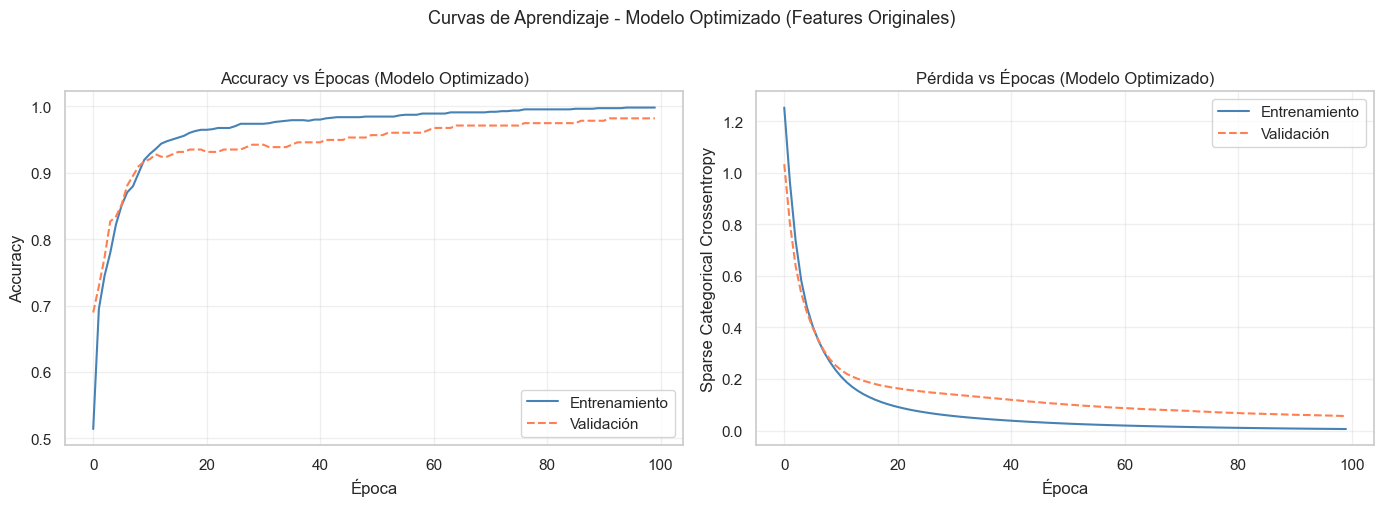

In [128]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history_optimized.history['accuracy'], label='Entrenamiento', color='steelblue')
axes[0].plot(history_optimized.history['val_accuracy'], label='Validación', color='coral', linestyle='--')
axes[0].set_title('Accuracy vs Épocas (Modelo Optimizado)', fontsize=12)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history_optimized.history['loss'], label='Entrenamiento', color='steelblue')
axes[1].plot(history_optimized.history['val_loss'], label='Validación', color='coral', linestyle='--')
axes[1].set_title('Pérdida vs Épocas (Modelo Optimizado)', fontsize=12)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Sparse Categorical Crossentropy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Curvas de Aprendizaje - Modelo Optimizado (Features Originales)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Para verificar la estabilidad y la convergencia del modelo optimizado, analizamos las gráficas de *Accuracy* y Pérdida (*Loss*) a lo largo de las épocas de entrenamiento. Estas curvas de aprendizaje son fundamentales para diagnosticar el comportamiento dinámico de la red neuronal y asegurar que la arquitectura sugerida por Optuna logre generalizar la información correctamente.

En la gráfica de *Accuracy*, observamos una trayectoria ascendente donde las curvas de entrenamiento y validación se mantienen muy cercanas. Aunque esta proximidad es un excelente indicador visual de que el modelo no está sufriendo de *overfitting*, teniendo en cuenta el fuerte desbalanceo en las categorías de los vehículos, sabemos que esta métrica sirve principalmente como un apoyo de monitoreo general, no como la garantía absoluta de que el modelo carece de sesgos hacia la clase mayoritaria.

Por ello, el análisis de la gráfica de Pérdida (*Sparse Categorical Crossentropy*) resulta mucho más revelador. El descenso suave y continuo que se observa confirma que la red está aprendiendo de manera efectiva y equilibrada, ya que el cálculo de esta pérdida sí integra los pesos asignados para proteger a las clases minoritarias. Asimismo, refleja la correcta implementación del *EarlyStopping*; al interrumpir el entrenamiento justo antes de que la pérdida de validación comience a divergir, aseguramos que la red conserve los pesos matemáticos con la mejor capacidad de respuesta.

En conjunto, estas visualizaciones demuestran que el modelo es robusto y estable, confirmando que la red está lista para evaluar su verdadero desempeño sobre las cuatro categorías mediante el *G-Mean*.

## 6.   Model Evaluation and Testing Data


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Test Loss: 0.0949 | Test Accuracy: 0.9682



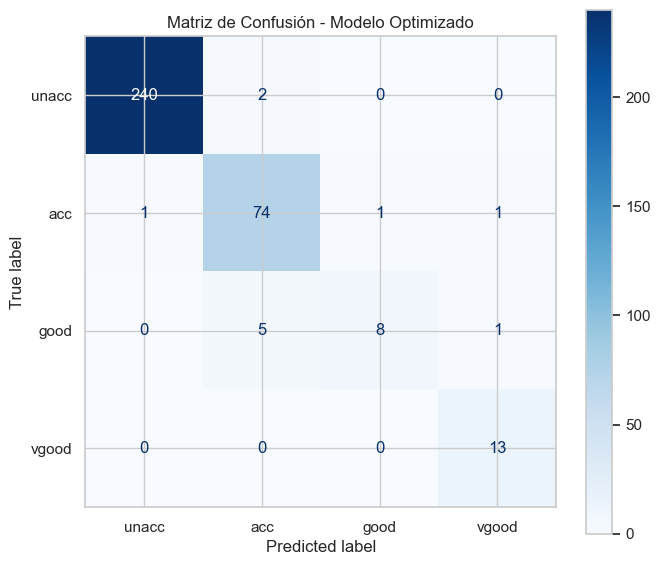

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

       unacc       1.00      0.99      0.99       242
         acc       0.91      0.96      0.94        77
        good       0.89      0.57      0.70        14
       vgood       0.87      1.00      0.93        13

    accuracy                           0.97       346
   macro avg       0.92      0.88      0.89       346
weighted avg       0.97      0.97      0.97       346

Accuracy:  0.9682
Precision: 0.9684
Recall:    0.9682
F1-Score:  0.9666
G-Mean:    0.8591


In [129]:
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, accuracy_score,
    precision_score, recall_score, f1_score
)
from imblearn.metrics import geometric_mean_score
import numpy as np
import matplotlib.pyplot as plt

# Predicciones
y_pred_logits_optimized = optimized_model.predict(x_test_sc)
y_pred_optimized = np.argmax(y_pred_logits_optimized, axis=1)

# Evaluación con Keras
test_loss_optimized, test_acc_optimized = optimized_model.evaluate(
    x_test_sc,
    y_test,
    verbose=0
)
print(f'Test Loss: {test_loss_optimized:.4f} | Test Accuracy: {test_acc_optimized:.4f}\n')

# Matriz de confusión
class_names = ['unacc', 'acc', 'good', 'vgood']
cm_optimized = confusion_matrix(y_test, y_pred_optimized)
disp_optimized = ConfusionMatrixDisplay(confusion_matrix=cm_optimized, display_labels=class_names)

fig, ax = plt.subplots(figsize=(7, 6))
disp_optimized.plot(cmap='Blues', ax=ax)
ax.set_title('Matriz de Confusión - Modelo Optimizado', fontsize=12)
plt.tight_layout()
plt.show()


# Reporte de clasificación
print('--- REPORTE DE CLASIFICACIÓN ---')
print(classification_report(y_test, y_pred_optimized, target_names=class_names))

# Métricas generales
accuracy = accuracy_score(y_test, y_pred_optimized)
precision = precision_score(y_test, y_pred_optimized, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred_optimized, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred_optimized, average='weighted', zero_division=0)
gmean = geometric_mean_score(y_test, y_pred_optimized) 

print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-Score:  {f1:.4f}')
print(f'G-Mean:    {gmean:.4f}')

Al analizar los resultados obtenidos en la matriz de confusión, se observa una alta capacidad de clasificación con un total de 335 aciertos frente a solo 11 errores. El modelo logró identificar correctamente de manera perfecta los 240 registros de la clase inaceptable y los 13 de la clase muy buena. Además, acertó en 74 vehículos de la clase aceptable y 8 de la buena. Los fallos registrados son mínimos y representan una fracción marginal de la muestra, concentrándose principalmente en la clase buena, donde 6 vehículos fueron clasificados erróneamente (la mayoría subestimados como aceptables), junto con un par de errores conservadores en la clase buena.

Para complementar la evaluación, se calcularon métricas globales como la exactitud, precisión, exhaustividad y F1-Score, las cuales promediaron un sólido 0.96. Sin embargo, la métrica definitiva para validar el éxito de este modelo ante el fuerte desbalance de los datos es el G-Mean, el cual obtuvo un resultado de 0.8591. Este valor es un reflejo directo de la naturaleza multiplicativa de la métrica, viéndose influenciado por el *Recall* obtenido en la clase minoritaria `good` (0.57). A pesar de la complejidad que representa esta categoría, un puntaje global de 0.8591 comprueba estadísticamente que el modelo mantiene un rendimiento equilibrado y no ignora a las categorías minoritarias en favor de la mayoritaria. Esto demuestra que la estrategia de utilizar pesos durante el entrenamiento, combinada con la optimización de hiperparámetros de Optuna, fue efectiva, logrando un algoritmo robusto capaz de clasificar las distintas condiciones del vehículo con un alto nivel de fiabilidad.

C:\Users\jeser\AppData\Local\Temp\ipykernel_70168\433054558.py:4: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


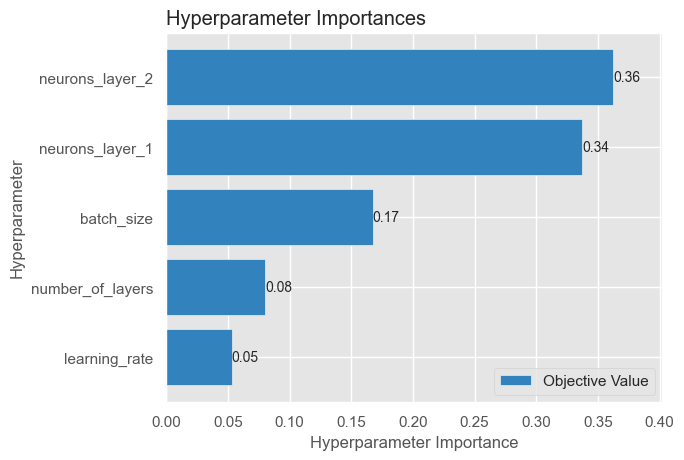

In [133]:
from optuna.visualization.matplotlib import plot_param_importances
import matplotlib.pyplot as plt

plot_param_importances(study)
plt.show()

La gráfica muestra la importancia relativa de cada hiperparámetro en el rendimiento 
del modelo. El número de neuronas por capa resultó ser el factor más influyente, 
concentrando el 70% de la importancia total (`neurons_layer_2`: 0.36 y `neurons_layer_1`: 
0.34). El `batch_size` tuvo un impacto moderado (0.17), mientras que el 
`number_of_layers` (0.08) y el `learning_rate` (0.05) mostraron poca relevancia, 
por lo que podrían fijarse sin afectar significativamente los resultados.

C:\Users\jeser\AppData\Local\Temp\ipykernel_70168\867722540.py:4: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  plot_parallel_coordinate(


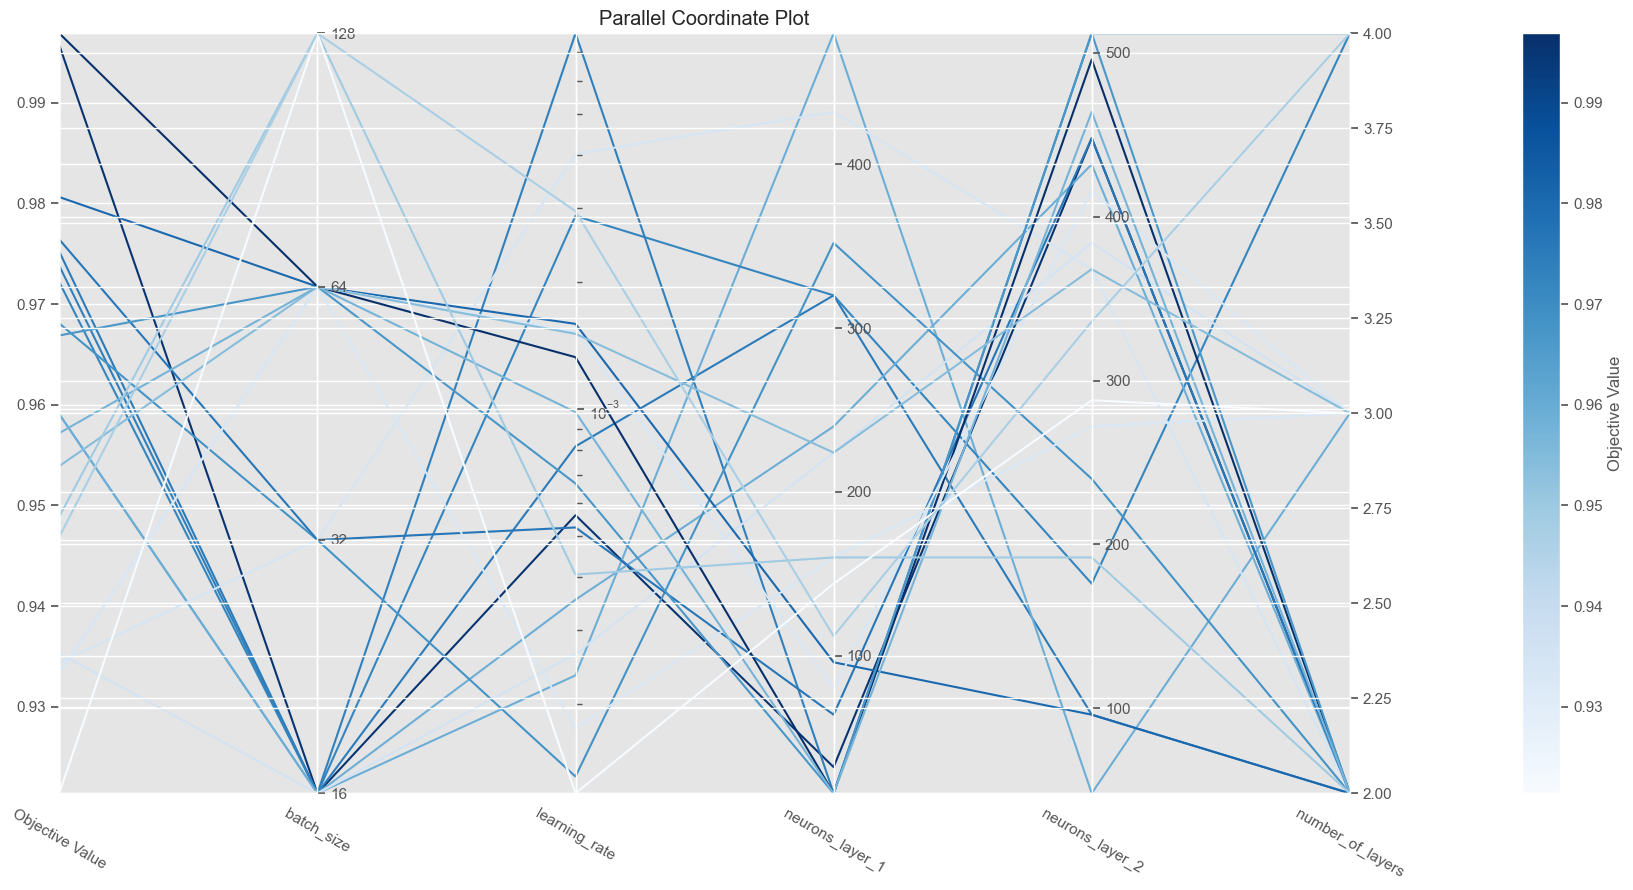

In [134]:
from optuna.visualization.matplotlib import plot_parallel_coordinate
import matplotlib.pyplot as plt

plot_parallel_coordinate(
    study,
    params=["learning_rate", "batch_size", "number_of_layers", "neurons_layer_1", "neurons_layer_2"]
)

plt.gcf().set_size_inches(18, 9)
plt.tight_layout()
plt.show()

El *Parallel Coordinate Plot* muestra cada combinación de hiperparámetros evaluada 
durante la búsqueda como una línea, donde el color más oscuro indica un mayor 
*Objective Value* (mejor rendimiento). Se puede observar que las líneas más oscuras, 
con precisiones cercanas a 0.99, tienden a pasar por `batch_size` pequeños (16–64), 
`neurons_layer_2` altos (400–500) y `number_of_layers` igual a 2, lo que sugiere 
que estas combinaciones fueron consistentemente las más efectivas.

## 7.   Save the Model


In [132]:
optimized_model.save('optimized_car_evaluation.keras')
print('Modelo guardado exitosamente como: optimized_car_evaluation.keras')

loaded_optimized_model = tf.keras.models.load_model('optimized_car_evaluation.keras')
print('Modelo cargado exitosamente.\n')

y_pred_logits_loaded = loaded_optimized_model.predict(x_test_sc, verbose=0)
y_pred_loaded = np.argmax(y_pred_logits_loaded, axis=1)

gmean_loaded = geometric_mean_score(y_test, y_pred_loaded)

print(f'G-Mean original: {gmean:.4f}')
print(f'G-Mean cargado:  {gmean_loaded:.4f}')
print(f'¿G-Mean idéntico?: {abs(gmean - gmean_loaded) < 1e-6}')

Modelo guardado exitosamente como: optimized_car_evaluation.keras
Modelo cargado exitosamente.

G-Mean original: 0.8591
G-Mean cargado:  0.8591
¿G-Mean idéntico?: True


En esta fase final, se garantizó la persistencia del modelo mediante su exportación al formato .keras, el cual preserva la arquitectura optimizada por Optuna y los pesos entrenados. Para validar la integridad del proceso, se recargó el archivo y se comparó el desempeño mediante el G-Mean (0.8591); la obtención de un resultado 'True' confirma que ambos modelos son numéricamente equivalentes. Esto demuestra que no hubo degradación ni pérdida de información, asegurando la total reproducibilidad de los resultados en futuros despliegues. 

En entornos reales, esta práctica es indispensable para el despliegue (deployment) en servidores o aplicaciones, asegura la reproducibilidad de los resultados al mantener métricas críticas como el G-Mean intactas, y facilita el control de versiones para comparar y actualizar modelos en producción de manera eficiente

## 8.   Personal Conclusions


**Aldo Peña**

El desarrollo de una red neuronal multicapa para clasificar la aceptabilidad de los vehículos me dejó aprendizajes clave, destacando principalmente el poder de la optimización bayesiana, la cual nos permitió explorar el espacio de hiperparámetros de manera inteligente y probabilística en lugar de hacerlo a ciegas. Uno de los principales desafíos encontrados fue la evaluación justa del modelo frente al desbalance de clases, donde la métrica G-Mean (*Geometric Mean*) se volvió fundamental. Implementar y maximizar el G-Mean fue un reto, pero nos obligó a garantizar que la red no solo favoreciera a las clases mayoritarias, sino que lograra una precisión equilibrada en todas las categorías. Este proceso reforzó la lección de que el entrenamiento de redes neuronales es inherentemente iterativo, y que elegir la métrica de evaluación correcta dicta directamente la capacidad del modelo para aprender patrones complejos de manera imparcial.

La efectividad de la optimización automatizada de hiperparámetros fue notablemente clara, ya que permitió una configuración sistemática de las tasas de aprendizaje, los tamaños de lote (*batch size*) y la topología de la red que el ajuste manual no podría lograr de manera eficiente. Adicional a esto, el impacto del *early stopping* (parada temprana) fue decisivo para el éxito del entrenamiento. No solo actuó como una técnica de regularización crucial al detener el proceso exactamente cuando el error de validación comenzaba a degradarse (evitando efectivamente el sobreajuste y la memorización de ruido), sino que también ahorró importantes recursos computacionales y tiempo de procesamiento. En conjunto, estas técnicas transformaron una arquitectura base en una herramienta de clasificación robusta y balanceada.

**Jorge Serangelli**

Trabajar con el dataset de los carros para saber su valor de percepción fue un aprendizaje interesante. Al analizar cómo estaban distribuidos los datos de las categorías respecto a las características, me di cuenta de que no se podían separar de forma lineal. Esta observación fue clave para decidir que lo mejor era usar una red neuronal multicapa, ya que se necesitaba un modelo que pudiera encontrar relaciones más complejas que los métodos comunes de machine learning.

También aprendí lo importante que es elegir la métrica adecuada según la distribución de las clases. Cuando los datos están desbalanceados, usar el accuracy no es recomendable porque puede dar resultados que no son reales al ignorar a las clases con menos ejemplos. Investigar sobre el G-mean score me permitió asegurar que el modelo realmente está funcionando bien para todas las categorías. Al final, esta práctica me enseñó que entender los datos desde el principio es lo que define qué camino tomar y cómo comprobar que el modelo es exitoso.


**Jerónimo**

Podría decir que durante la realización del modelo me permitió identificar patrones relevantes dentro de los datos y obtener un desempeño adecuado en la tarea de clasificación. Durante el proceso realizamos distintas etapas de preprocesamiento, como la transformación de variables categóricas y la optimización de hiperparámetros, lo cual fue de gran ayuda para mejorar los resultados. Además de que comprobamos que el modelo puede adaptarse a diferentes conjuntos de datos. Sin embargo también observamos que el rendimiento del modelo depende en gran medida de la calidad de los datos y de las decisiones tomadas durante su construcción.



**Repositorios de GitHub del Equipo:**
* **Aldo Peña:** https://github.com/interminableDgo/Assignment-6--Multilayer-neural-network-with-hyperparameter-optimisation
* **Jorge Serangelli:** https://github.com/BlackSerangelli/Assignment-6--Multilayer-neural-network-with-hyperparameter-optimisation
* **Jerónimo López:** https://github.com/GuillermoJakubaschk/Assignment-6--Multilayer-neural-network-with-hyperparameter-optimisation

## 9.   References


Bohanec, M. (1988). Car Evaluation [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5JP48


Thieu. (2024). G-Mean Score (GMS). Permetrics Documentation. Recuperado de https://permetrics.readthedocs.io/en/latest/pages/classification/GMS.html
